# Predicting Heart Disease

### Импорт библиотек

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score
from tqdm.auto import trange
from IPython.display import clear_output

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator

import torch
import torch.nn as nn
import torch.utils.data as data
import torch.optim as optim

from catboost import CatBoostClassifier

#### Соединим два набора данных

In [84]:
df1 = pd.read_csv('data/heart_desease_data.csv.xls')
df2 = pd.read_csv('data/train.csv')

df1['id'] = np.arange(start=len(df2), stop=len(df2) + len(df1))
df1.rename(
    columns={
        'age' : 'Age',
        'sex' : 'Sex',
        'cp' : 'Chest pain type',
        'trestbps' : 'BP',
        'chol' : 'Cholesterol',
        'fbs' : 'FBS over 120',
        'restecg' : 'EKG results',
        'thalach' : 'Max HR',
        'exang' : 'Exercise angina',
        'oldpeak' : 'ST depression',
        'slope' : 'Slope of ST',
        'ca' : 'Number of vessels fluro',
        'thal' : 'Thallium',
        'target' : 'Heart Disease'
    }, inplace=True
)
df2['Heart Disease'] = (df2['Heart Disease'] == 'Presence').astype(int)

df = pd.concat([df1, df2], ignore_index=True)

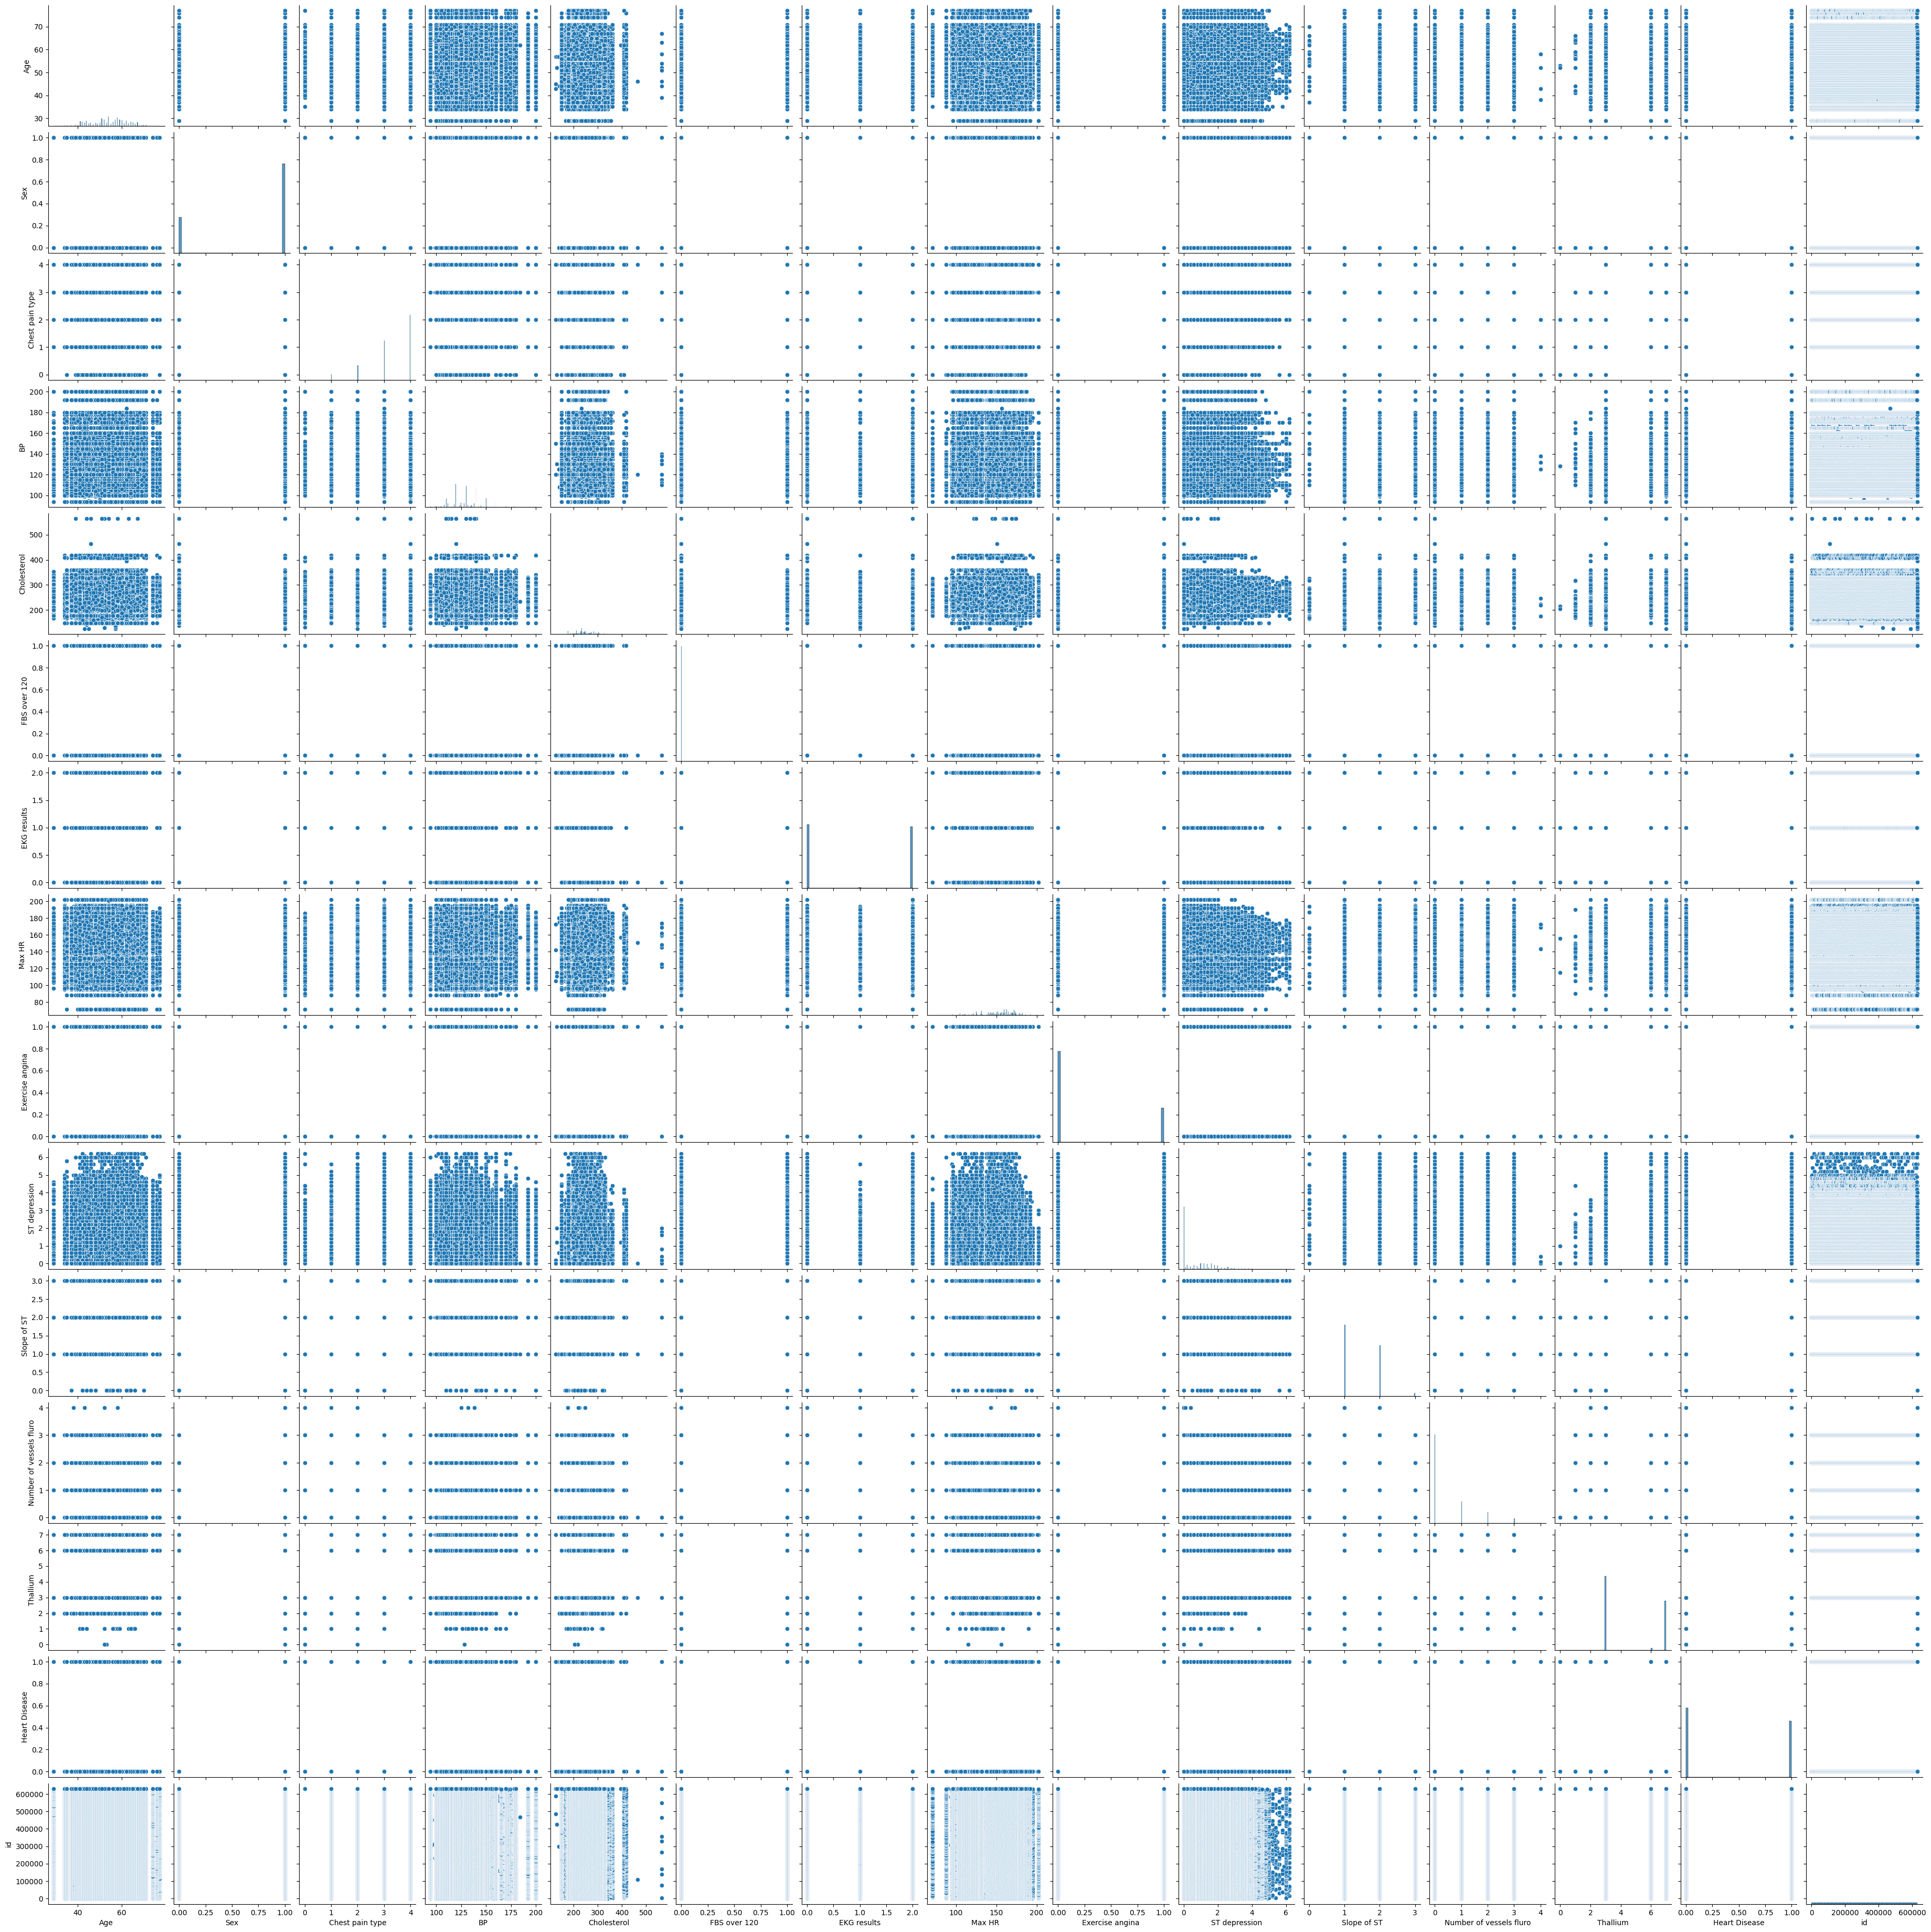

In [67]:
sns.pairplot(df)
plt.show()

In [88]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=33)
df_test, df_val = train_test_split(df_test, test_size=0.5, random_state=33)

In [89]:
for c in df.columns:
    un = df_train[c].unique()
    if un.shape[0] > 100:
        print(f'Column {c}: unique values count: {len(un)}')
    else: 
        print(f'Column {c}: unique values count: {len(un)}, unique values: {un}')

Column Age: unique values count: 42, unique values: [59 54 51 48 62 64 34 60 37 42 44 67 66 58 47 56 76 52 41 46 61 70 68 43
 45 50 65 40 57 63 53 55 69 71 29 39 49 35 77 38 74 75]
Column Sex: unique values count: 2, unique values: [0 1]
Column Chest pain type: unique values count: 5, unique values: [3 4 2 1 0]
Column BP: unique values count: 65, unique values: [140 128 112 110  94 130 150 120 145 132 105 138 152 160 102 134 136 118
 125 174 106 124 180 155 126 170 101 178 146 158 122 135 168 104 108 142
 148 100 115 200 192 165 111 144 156 123 172 117 129  96 149 154 114  95
 141 109 175 127  99 116 133 103 162 131 147]
Column Cholesterol: unique values count: 159
Column FBS over 120: unique values count: 2, unique values: [0 1]
Column EKG results: unique values count: 3, unique values: [0 2 1]
Column Max HR: unique values count: 93, unique values: [172 150 162 173 152 151 147 129 111 174 160 130 132 148 142 122 146 182
 161  95 105 126 170 159 158 165 156 171 184 168 163 169 125 128 

In [108]:
cat_cols = ['Chest pain type', 'EKG results', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
num_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

In [138]:
mlp_pipeline = Pipeline([
    ('OneHotEncoder', ColumnTransformer([
        ('', OneHotEncoder(sparse_output=False), cat_cols)
    ], remainder='passthrough', verbose_feature_names_out=False)),
    ('StandardScaler', ColumnTransformer([
        ('', StandardScaler(), num_cols),
    ], remainder='passthrough', verbose_feature_names_out=False))
])

mlp_pipeline.set_output(transform='pandas')

X_train, y_train = mlp_pipeline.fit_transform(df_train).drop(['Heart Disease', 'id'], axis=1), df_train['Heart Disease']
X_val, y_val = mlp_pipeline.transform(df_val).drop(['Heart Disease', 'id'], axis=1), df_val['Heart Disease']
X_test, y_test = mlp_pipeline.transform(df_test).drop(['Heart Disease', 'id'], axis=1), df_test['Heart Disease']

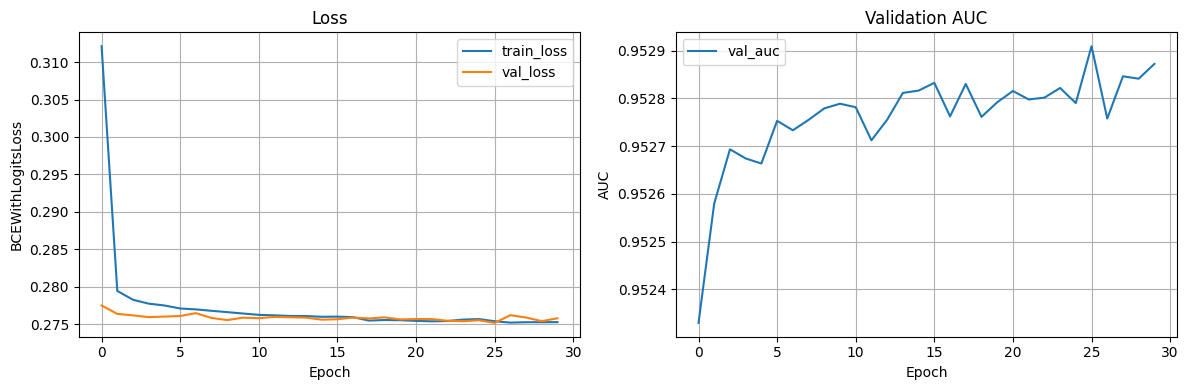

Epoch 30/30 | train_loss=0.2753 | val_loss=0.2758 | val_auc=0.9529 | val_acc=0.8866 | best_val_auc=0.9529

Final test metrics:
TEST loss: 0.2751
TEST AUC:  0.9528
TEST ACC:  0.8859


In [148]:
mlp = nn.Sequential(
    nn.LazyLinear(256),
    nn.Tanh(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.2),

    nn.Linear(256, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.2),

    nn.Linear(512, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.2),

    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.1),

    nn.Linear(64, 1)
)

X_train_tensor = torch.tensor(X_train.values.astype(np.float32))
y_train_tensor = torch.tensor(y_train.values.astype(np.float32)).unsqueeze(1)

X_val_tensor = torch.tensor(X_val.values.astype(np.float32))
y_val_tensor = torch.tensor(y_val.values.astype(np.float32)).unsqueeze(1)

X_test_tensor = torch.tensor(X_test.values.astype(np.float32))
y_test_tensor = torch.tensor(y_test.values.astype(np.float32)).unsqueeze(1)

train_dataset = data.TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = data.TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader = data.DataLoader(train_dataset, batch_size=16384, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=16384, shuffle=False)
test_loader = data.DataLoader(test_dataset, batch_size=16384, shuffle=False)


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
mlp = mlp.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 30

best_val_auc = -np.inf
best_state = None

train_loss_history = []
val_loss_history = []
val_auc_history = []

for epoch in range(num_epochs):
    mlp.train()
    batch_train_losses = []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = mlp(X_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_train_losses.append(loss.item())
    
    mean_train_loss = float(np.mean(batch_train_losses))
    train_loss_history.append(mean_train_loss)

    mlp.eval()
    batch_val_losses = []
    val_probs = []
    val_targets = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = mlp(X_batch)
            loss = criterion(logits, y_batch)
            probs = torch.sigmoid(logits)

            batch_val_losses.append(loss.item())
            val_probs.append(probs.cpu())
            val_targets.append(y_batch.cpu())

    mean_val_loss = float(np.mean(batch_val_losses))
    val_loss_history.append(mean_val_loss)

    val_probs = torch.cat(val_probs).numpy().ravel()
    val_targets = torch.cat(val_targets).numpy().ravel()

    val_auc = roc_auc_score(val_targets, val_probs)
    val_auc_history.append(val_auc)

    val_pred = (val_probs >= 0.5).astype(np.float32)
    val_acc = accuracy_score(val_targets, val_pred)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = {k: v.detach().cpu().clone() for k, v in mlp.state_dict().items()}

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(train_loss_history, label="train_loss")
    axes[0].plot(val_loss_history, label="val_loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("BCEWithLogitsLoss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(val_auc_history, label="val_auc")
    axes[1].set_title("Validation AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("AUC")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"train_loss={mean_train_loss:.4f} | "
        f"val_loss={mean_val_loss:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"best_val_auc={best_val_auc:.4f}"
    )

if best_state is not None:
    mlp.load_state_dict(best_state)

mlp = mlp.to(device)
mlp.eval()

test_probs = []
test_targets = []
test_losses = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = mlp(X_batch)
        loss = criterion(logits, y_batch)
        probs = torch.sigmoid(logits)

        test_losses.append(loss.item())
        test_probs.append(probs.cpu())
        test_targets.append(y_batch.cpu())

test_probs = torch.cat(test_probs).numpy().ravel()
test_targets = torch.cat(test_targets).numpy().ravel()
test_pred = (test_probs >= 0.5).astype(np.float32)

test_loss = float(np.mean(test_losses))
test_auc = roc_auc_score(test_targets, test_probs)
test_acc = accuracy_score(test_targets, test_pred)

print("\nFinal test metrics:")
print(f"TEST loss: {test_loss:.4f}")
print(f"TEST AUC:  {test_auc:.4f}")
print(f"TEST ACC:  {test_acc:.4f}")

In [225]:
train_df_catboost = pd.read_csv('data/train.csv')
train_df_catboost['Heart Disease'] = (train_df_catboost['Heart Disease'] == 'Presence').astype(int)
y_cb = train_df_catboost['Heart Disease']
X_cb = train_df_catboost.drop(labels=['id', 'Heart Disease'], axis=1)

In [226]:
cb_params = { # были подобраны optuna
    'iterations': 6000,
    'learning_rate': 0.010934361423007594,
    'depth': 4, 
    'l2_leaf_reg': 5.3083618108460815,
    'random_strength': 1.2363531018093865,
    'bagging_temperature': 2.407487952762692,
    'border_count': 183,
    'leaf_estimation_method': 'Newton',
    "loss_function": "Logloss",
    "random_seed": 42,
    "verbose": 200,
    "allow_writing_files": False,
}


final_model = CatBoostClassifier(**cb_params)

final_model.fit(X_cb, y_cb)

0:	learn: 0.6828492	total: 62.6ms	remaining: 6m 15s
200:	learn: 0.2986553	total: 6.05s	remaining: 2m 54s
400:	learn: 0.2779986	total: 12.3s	remaining: 2m 51s
600:	learn: 0.2734235	total: 17.9s	remaining: 2m 40s
800:	learn: 0.2718001	total: 23.5s	remaining: 2m 32s
1000:	learn: 0.2709885	total: 28.9s	remaining: 2m 24s
1200:	learn: 0.2704279	total: 34.1s	remaining: 2m 16s
1400:	learn: 0.2699832	total: 39.4s	remaining: 2m 9s
1600:	learn: 0.2695752	total: 45s	remaining: 2m 3s
1800:	learn: 0.2692198	total: 50.7s	remaining: 1m 58s
2000:	learn: 0.2688911	total: 56.2s	remaining: 1m 52s
2200:	learn: 0.2685528	total: 1m 1s	remaining: 1m 46s
2400:	learn: 0.2682578	total: 1m 7s	remaining: 1m 40s
2600:	learn: 0.2679747	total: 1m 12s	remaining: 1m 35s
2800:	learn: 0.2677661	total: 1m 19s	remaining: 1m 30s
3000:	learn: 0.2675653	total: 1m 25s	remaining: 1m 25s
3200:	learn: 0.2673816	total: 1m 30s	remaining: 1m 19s
3400:	learn: 0.2672471	total: 1m 36s	remaining: 1m 13s
3600:	learn: 0.2671305	total: 1m 

CatBoostClassifier(allow_writing_files=False, bagging_temperature=2.407487952762692, border_count=183, depth=4, iterations=6000, l2_leaf_reg=5.3083618108460815, leaf_estimation_method='Newton', learning_rate=0.010934361423007594, loss_function='Logloss', random_seed=42, random_strength=1.2363531018093865, verbose=200)

In [ ]:
sub_df_for_mlp = pd.read_csv('data/test.csv')
X_sub_mlp = mlp_pipeline.transform(sub_df_for_mlp)

In [181]:
X_sub_mlp_tensor = torch.tensor(X_sub_mlp.drop(labels=['id', 'Heart Disease'], axis=1).values.astype(np.float32))
sub_mlp_dataset = data.TensorDataset(X_sub_mlp_tensor)

In [182]:
X_sub_mlp_tensor

tensor([[ 0.4672, -0.7016,  1.2753,  ...,  1.0000,  0.0000,  1.0000],
        [ 0.1039, -0.7016, -1.0686,  ...,  0.0000,  0.0000,  0.0000],
        [-0.0172, -0.7016,  0.6819,  ...,  1.0000,  0.0000,  1.0000],
        ...,
        [ 1.0728, -1.5025, -1.3060,  ...,  1.0000,  1.0000,  0.0000],
        [ 0.5883, -0.7016,  0.8599,  ...,  1.0000,  0.0000,  0.0000],
        [-1.4706, -0.7016,  0.8896,  ...,  1.0000,  0.0000,  0.0000]])

In [218]:
with torch.no_grad():
    mlp.eval()
    mlp_sub_probs = mlp(X_sub_mlp_tensor.to(device))

In [219]:
mlp_sub_probs = torch.sigmoid(mlp_sub_probs.squeeze())
probs_mlp = mlp_sub_probs.cpu().numpy()
probs_mlp

array([0.93236446, 0.00543722, 0.98632914, ..., 0.05503634, 0.3046284 ,
       0.02620571], shape=(270000,), dtype=float32)

In [220]:
sub_df_for_mlp['Heart Disease'] = probs_mlp
sub_df_for_mlp[['id', 'Heart Disease']].to_csv('submission_mlp.csv', index=False)

In [227]:
sub_df_for_cb = pd.read_csv('data/test.csv')
X_sub_for_cb = sub_df_for_cb.drop('id', axis=1)

In [230]:
cb_probs = final_model.predict_proba(X_sub_for_cb)[:, 1]

In [231]:
sub_df_for_cb['Heart Disease'] = cb_probs
sub_df_for_cb[['id', 'Heart Disease']].to_csv('submission_cb.csv', index=False)

In [242]:
pd.concat((pd.read_csv('data/test.csv')['id'], pd.Series(cb_probs * probs_mlp, name='Heard Disease')), axis=1).to_csv('submission_mult.csv', index=False)